Condional Workflow for Post review

In [1]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph, START, END

In [2]:
class ModerationState(TypedDict):
    post_content: str
    user_reputation: str

    formatted_post: str
    content_flag: str
    result: str

In [3]:
def format_post(state: ModerationState) -> ModerationState:
    # Format the post content (e.g., remove extra spaces, fix capitalization)
    formatted_content = f"User: {state['user_reputation']}\nContent: {state['post_content'].strip().capitalize()}"
    return {'formatted_post': formatted_content}

In [4]:
def analyze_post(state: ModerationState) -> ModerationState:
    # Analyze the post content for inappropriate language or spam
    if "spam" in state["formatted_post"].lower() or "buy now" in state["formatted_post"].lower():
        flag = "rejected"
    elif "new_user" in state["user_reputation"].lower():
        flag = "review"
    else:
        flag = "approve"
    return {'content_flag': flag}

In [5]:
def approve_post(state: ModerationState):
    # Approve the post
    result = "Post approved and published."
    return {'result': result}

In [6]:
def flag_for_review(state: ModerationState):
    # Flag the post for manual review
    result = "Post flagged for manual review."
    return {'result': result}

In [7]:
def reject_post(state: ModerationState):
    # Reject the post
    result = "Post rejected due to inappropriate content."
    return {'result': result}

In [8]:
def decide_the_node(state: ModerationState) -> Literal["approve_post", "flag_for_review", "reject_post"]:
    if state["content_flag"] == "approve":
        return "approve_post"
    elif state["content_flag"] == "review":
        return "flag_for_review"
    else:
        return "reject_post"

In [9]:
graph = StateGraph(ModerationState)

##Add Nodes
graph.add_node("format_post",format_post)
graph.add_node("analyze_post",analyze_post)
graph.add_node("approve_post",approve_post)
graph.add_node("flag_for_review",flag_for_review)
graph.add_node("reject_post",reject_post)

##Add Edges
graph.add_edge(START, "format_post")
graph.add_edge("format_post", "analyze_post")

graph.add_edge("analyze_post", END)
graph.add_conditional_edges("analyze_post", decide_the_node)

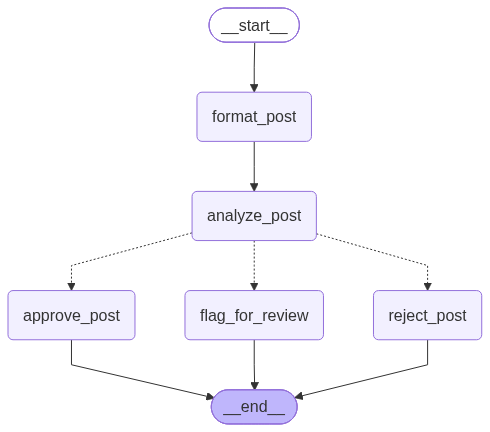

In [10]:
workflow = graph.compile()
workflow

In [15]:
user_input={
    "post_content": "   This is a sample post content. Buy now!",
    "user_reputation": "old_user"
}
workflow.invoke(user_input)

{'post_content': '   This is a sample post content. Buy now!',
 'user_reputation': 'old_user',
 'formatted_post': 'User: old_user\nContent: This is a sample post content. buy now!',
 'content_flag': 'rejected',
 'result': 'Post rejected due to inappropriate content.'}